# Comparativa de Algoritmos de Clustering con Embeddings de Nomic

Este notebook experimenta y compara los resultados obtenidos al agrupar textos de intención de usuarios bancarios (una fracción del dataset banking77) utilizando diferentes enfoques de clustering sobre representaciones generadas por Ollama (`nomic-embed-text`).

Los enfoques a comparar son:
1. K-Means (Euclidea)
2. K-Means (Coseno)
3. Fuzzy C-Means (Euclidea)
4. Fuzzy C-Means (Coseno)

Adicionalmente, se probará una configuración extra reduciendo dimensionalidad usando UMAP antes del clustering.

Se evaluarán usando los siguientes criterios (expuestos en `capitulos/Fundamentos.tex`):
- Internos: ASW (Silueta), CH (Calinski-Harabasz), y para FCM: PC, PE, XB.
- Externos: ARI (Adjusted Rand Index) y NMI (Normalized Mutual Information).


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import warnings

warnings.filterwarnings('ignore')

# Agregar directorio validation al path para poder importar nuestros modulos custom
sys.path.append(os.path.abspath('../..'))

from clustering import GenericKMeans, get_closest_to_centroid
from representation.ollama_embeddings import OllamaEmbeddings
from metrics.metrics import evaluate_hard_clustering, evaluate_fuzzy_clustering


In [2]:
from pathlib import Path

# Resolver el root del repositorio y preparar una carpeta local para artefactos del experimento
CANDIDATE_ROOT = Path.cwd().resolve()
if CANDIDATE_ROOT.name == "notebooks" and CANDIDATE_ROOT.parent.name == "validation":
    ROOT = CANDIDATE_ROOT.parent.parent
else:
    ROOT = next(
        (p for p in [CANDIDATE_ROOT, *CANDIDATE_ROOT.parents] if (p / "validation").exists()),
        CANDIDATE_ROOT,
    )

RESULTS_ROOT = ROOT / "validation" / "results" / "04_clustering_experiments"
TABLES_DIR = RESULTS_ROOT / "tables"
FIGURES_DIR = RESULTS_ROOT / "figures"
for path in [RESULTS_ROOT, TABLES_DIR, FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(f"ROOT: {ROOT}")
print(f"Resultados: {RESULTS_ROOT}")

ROOT: /home/gabriel/clase/TFG/TFG-Chatbot
Resultados: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/04_clustering_experiments


## 1. Carga de Datos
Cargamos el subconjunto extraído de banking77 con sentencias que tienen alto overlap semántico.


In [3]:
# Load Dataset
dataset_path = '../../results/banking77_eda/tables/banking77_similar8_subset.csv'
df = pd.read_csv(dataset_path)
print(f"Dataset shape: {df.shape}")
print("Label distribution:")
print(df['label'].value_counts())

texts = df['text'].tolist()
true_labels = df['label'].tolist()

label_to_idx = {label: idx for idx, label in enumerate(np.unique(true_labels))}
true_labels_idx = np.array([label_to_idx[l] for l in true_labels])


Dataset shape: (1176, 4)
Label distribution:
label
cash_withdrawal_charge            177
card_payment_not_recognised       168
cash_withdrawal_not_recognised    160
beneficiary_not_allowed           156
card_arrival                      153
card_linking                      139
card_delivery_estimate            112
card_not_working                  111
Name: count, dtype: int64


## 2. Generación de Embeddings usando Nomic
Nos conectamos a la instancia local de Ollama para obtener text embeddings. Asegúrate de tener ollama ejecutándose y el modelo `nomic-embed-text` descargado (`ollama pull nomic-embed-text`).


In [4]:
embedder = OllamaEmbeddings(model="nomic-embed-text", host="localhost", port=11434)
embeddings = embedder.embed_batch(texts, normalize=True)
print(f"Embeddings shape: {embeddings.shape}")


Embeddings shape: (1176, 768)


## 3. Experimentos de Clustering


In [5]:
# Definimos los hiperparámetros
k_values = [3, 5, 8, 10, 12, 15] # 8 es importante porque es el numero de categorias unicas reales
seeds = [42, 123, 2024]
configurations = [
    {"algorithm": "kmeans", "distance": "euclidean"},
    {"algorithm": "kmeans", "distance": "cosine"},
    {"algorithm": "fcm", "distance": "euclidean"},
    {"algorithm": "fcm", "distance": "cosine"}
]

results = []
models_cache = {} # Cache parameters and models for qualitative exploration later

for seed in seeds:
    for k in k_values:
        for config in configurations:
            alg_name = f"{config['algorithm']}_{config['distance']}"
            model_key = f"{alg_name}_k{k}_s{seed}"
            
            # Inicializamos modelo
            model = GenericKMeans(
                n_clusters=k,
                algorithm=config['algorithm'],
                distance=config['distance'],
                random_state=seed,
                max_iter=300
            )
            
            # Fit el modelo a los embeddings
            model.fit(embeddings)
            
            row = {
                "Algorithm": alg_name,
                "k": k,
                "Seed": seed
            }
            
            if config['algorithm'] == 'kmeans':
                pred_labels = model.labels_
                metrics = evaluate_hard_clustering(embeddings, pred_labels, metric=config['distance'])
                row['ASW'] = metrics.asw
                row['CH'] = metrics.ch
                row['PC'] = np.nan
                row['PE'] = np.nan
                row['XB'] = np.nan
            else:
                membership = model.membership_
                pred_labels = model.labels_
                metrics = evaluate_fuzzy_clustering(embeddings, membership, model.centroids_, distance=config['distance'])
                row['ASW'] = metrics.asw
                row['CH'] = metrics.ch
                row['PC'] = metrics.pc
                row['PE'] = metrics.pe
                row['XB'] = metrics.xb
                
            # Metricas Externas
            row['ARI'] = adjusted_rand_score(true_labels_idx, pred_labels)
            row['NMI'] = normalized_mutual_info_score(true_labels_idx, pred_labels)
            
            results.append(row)
            models_cache[model_key] = {"model": model, "labels": pred_labels, "config": config}

results_df = pd.DataFrame(results)


### Agrupación y Resumen de Resultados


In [6]:
# Resumimos los resultados agrupando por Algorithm y k (promediando las diferentes seeds)
summary_df = results_df.groupby(['Algorithm', 'k']).mean(numeric_only=True).reset_index()

results_df.to_csv(TABLES_DIR / "results_raw.csv", index=False, encoding="utf-8")
summary_df.to_csv(TABLES_DIR / "results_summary.csv", index=False, encoding="utf-8")

display(summary_df)
print(f"Resultados guardados en: {TABLES_DIR}")

,Algorithm,k,Seed,ASW,CH,PC,PE,XB,ARI,NMI
0,fcm_cosine,3,729.666667,0.162709,107.207169,0.333595,1.098220,6.098024e+06,0.248080,0.433832
1,fcm_cosine,5,729.666667,0.069985,62.272668,0.200115,1.609149,8.021699e+07,0.242079,0.421991
2,fcm_cosine,8,729.666667,0.087780,58.347159,0.140140,2.027181,2.762310e+08,0.429684,0.568521
3,fcm_cosine,10,729.666667,0.074123,52.160783,0.122214,2.203487,4.727456e+07,0.444226,0.608522
4,fcm_cosine,12,729.666667,0.032027,43.030650,0.093836,2.430698,1.127853e+08,0.416251,0.597203
5,fcm_cosine,15,729.666667,0.048719,41.806780,0.082925,2.605418,2.221609e+10,0.443111,0.613106
6,fcm_euclidean,3,729.666667,0.090217,149.898844,0.333333,1.098612,1.569376e+07,0.202640,0.385551
7,fcm_euclidean,5,729.666667,0.128675,179.381393,0.200000,1.609438,5.146154e+08,0.201870,0.383993
8,fcm_euclidean,8,729.666667,0.102748,149.689969,0.125000,2.079442,5.870538e+09,0.202069,0.384487
9,fcm_euclidean,10,729.666667,0.128675,179.381393,0.100000,2.302585,1.449337e+10,0.201870,0.383993


Resultados guardados en: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/04_clustering_experiments/tables


## 4. Experimento UMAP + Clustering
Reduciremos dimensionalidad a 2D y probaremos nuevamente.


In [7]:
import umap.umap_ as umap

reducer = umap.UMAP(n_components=2, metric='cosine', random_state=42)
umap_embeddings = reducer.fit_transform(embeddings)

results_umap = []
models_umap_cache = {}

for seed in seeds:
    for k in k_values:
        for config in configurations:
            alg_name = f"{config['algorithm']}_{config['distance']}"
            model_key = f"{alg_name}_k{k}_s{seed}"
            
            # Inicializamos modelo
            model = GenericKMeans(n_clusters=k, algorithm=config['algorithm'], distance=config['distance'], random_state=seed)
            model.fit(umap_embeddings)
            
            row = {"Algorithm": alg_name, "k": k, "Seed": seed}
            if config['algorithm'] == 'kmeans':
                pred_labels = model.labels_
                metrics = evaluate_hard_clustering(umap_embeddings, pred_labels, metric=config['distance'])
                row['ASW'] = metrics.asw; row['CH'] = metrics.ch
                row['PC'] = np.nan; row['PE'] = np.nan; row['XB'] = np.nan
            else:
                pred_labels = model.labels_
                metrics = evaluate_fuzzy_clustering(umap_embeddings, model.membership_, model.centroids_, distance=config['distance'])
                row['ASW'] = metrics.asw; row['CH'] = metrics.ch
                row['PC'] = metrics.pc; row['PE'] = metrics.pe; row['XB'] = metrics.xb
                
            row['ARI'] = adjusted_rand_score(true_labels_idx, pred_labels)
            row['NMI'] = normalized_mutual_info_score(true_labels_idx, pred_labels)
            
            results_umap.append(row)
            models_umap_cache[model_key] = {"model": model, "labels": pred_labels, "config": config}

results_umap_df = pd.DataFrame(results_umap)
summary_umap_df = results_umap_df.groupby(['Algorithm', 'k']).mean(numeric_only=True).reset_index()

results_umap_df.to_csv(TABLES_DIR / "results_umap_raw.csv", index=False, encoding="utf-8")
summary_umap_df.to_csv(TABLES_DIR / "results_umap_summary.csv", index=False, encoding="utf-8")

print(f"Resultados UMAP guardados en: {TABLES_DIR}")


Resultados UMAP guardados en: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/04_clustering_experiments/tables


## 5. Visualización de la Variación de Métricas
Comparamos el rendimiento general usando las métricas NMI y ASW a través de los valores de k.


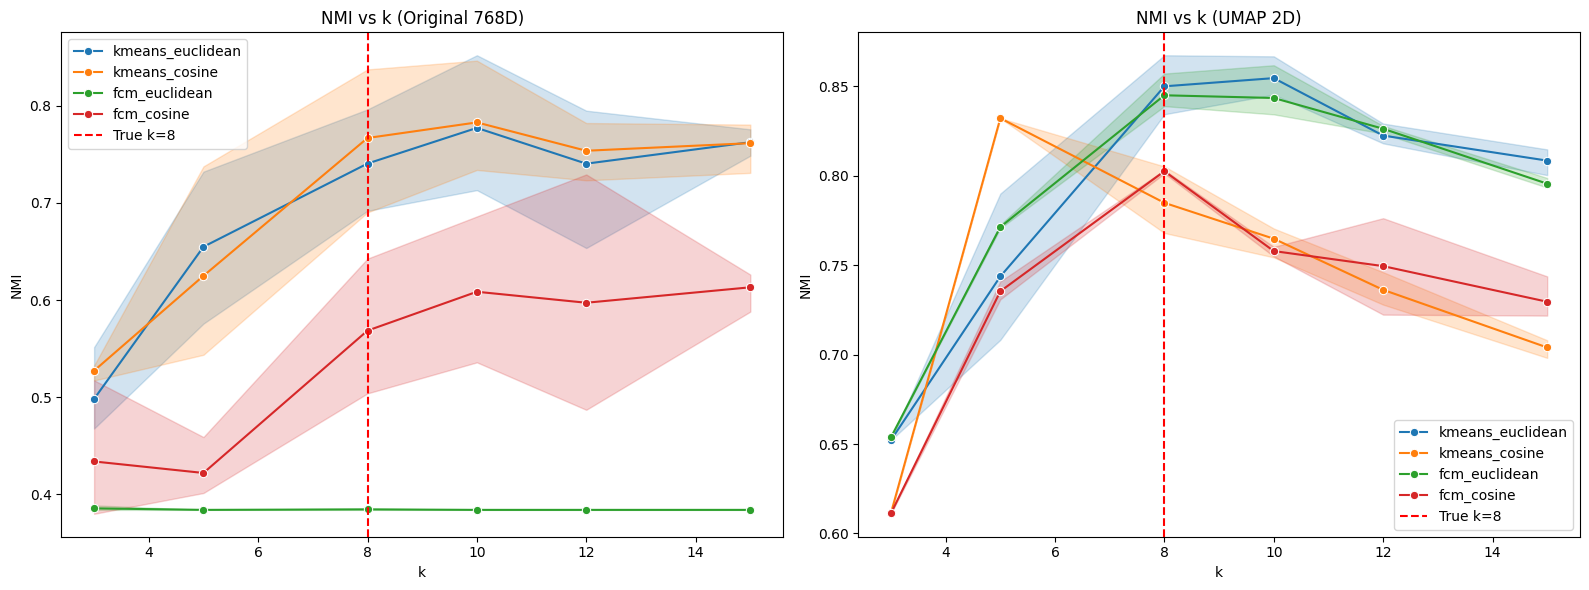

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(data=results_df, x='k', y='NMI', hue='Algorithm', marker='o', ax=ax1)
ax1.set_title('NMI vs k (Original 768D)')
ax1.axvline(x=8, color='red', linestyle='--', label='True k=8')
ax1.legend()

sns.lineplot(data=results_umap_df, x='k', y='NMI', hue='Algorithm', marker='o', ax=ax2)
ax2.set_title('NMI vs k (UMAP 2D)')
ax2.axvline(x=8, color='red', linestyle='--', label='True k=8')
ax2.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "nmi_vs_k_comparison.png", dpi=180, bbox_inches="tight")
plt.show()


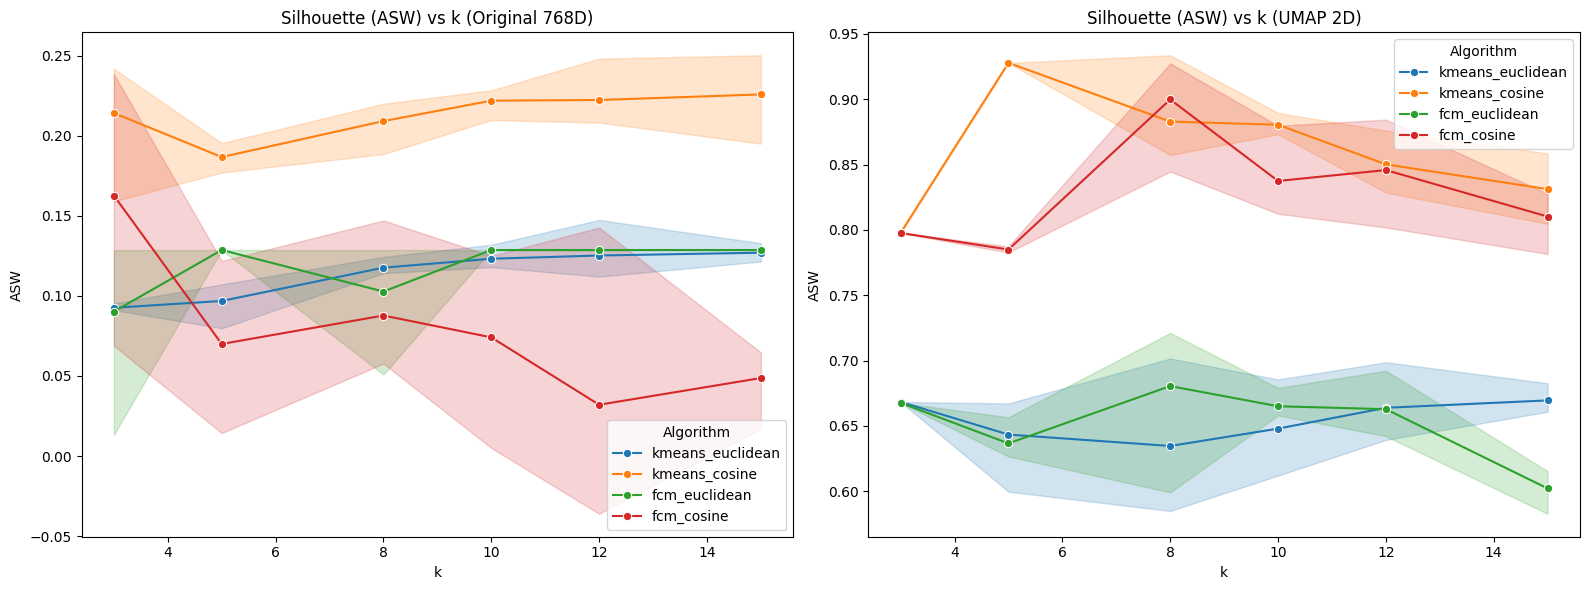

In [9]:
# Comparamos Silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.lineplot(data=results_df, x='k', y='ASW', hue='Algorithm', marker='o', ax=ax1)
ax1.set_title('Silhouette (ASW) vs k (Original 768D)')
sns.lineplot(data=results_umap_df, x='k', y='ASW', hue='Algorithm', marker='o', ax=ax2)
ax2.set_title('Silhouette (ASW) vs k (UMAP 2D)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "asw_vs_k_comparison.png", dpi=180, bbox_inches="tight")
plt.show()


## 6. Validación Cualitativa de Resultados
Nos enfocaremos en el mejor escenario original en base al NMI promedio a k=8 e imprimiremos el centroide y los ejemplos cercanos en cada cluster formado.


In [10]:
# Obtengamos la mejor configuracion para k=8 original
k8_results = summary_df[summary_df['k'] == 8].sort_values(by='NMI', ascending=False)
best_config_k8 = k8_results.iloc[0]['Algorithm']
print(f"El mejor algoritmo para k=8 es: {best_config_k8} (NMI: {k8_results.iloc[0]['NMI']:.4f})")

# Vamos a explorar una semilla aleatoria particular para este modelo
explore_seed = 42
model_key = f"{best_config_k8}_k8_s{explore_seed}"
cached_data = models_cache[model_key]

model = cached_data['model']
pred_labels = cached_data['labels']
config = cached_data['config']

# Obtenemos los representantes de cada cluster
representatives_idx = get_closest_to_centroid(embeddings, pred_labels, model.centroids_, distance=config['distance'])

print("\n" + "="*80)
print(f"Validación Cualitativa (k=8, Configuración: {best_config_k8})")
print("="*80)

for cluster_id, rep_idx in enumerate(representatives_idx):
    print(f"\n--- CLUSTER {cluster_id} ---")
    rep_text = df.iloc[rep_idx]['text']
    rep_true = df.iloc[rep_idx]['label']
    print(f"[*] CENTROIDE REPRESENTATIVO: '{rep_text}' (Etiqueta real: {rep_true})\n")
    
    # Textos en este cluster
    cluster_indices = np.where(pred_labels == cluster_id)[0]
    
    # Calcular distancia de todos los del cluster al centroide para mostrarlos ordenados
    cluster_emb = embeddings[cluster_indices]
    centroid = model.centroids_[cluster_id]
    
    if config['distance'] == 'cosine':
        # Distancia coseno al centroide (menor es mas cercano)
        dists = 1.0 - np.dot(cluster_emb, centroid)
    else:
        dists = np.linalg.norm(cluster_emb - centroid, axis=1)
        
    sorted_local_indices = np.argsort(dists)
    
    print("Documentos más cercanos en este cluster:")
    for i in range(min(5, len(sorted_local_indices))):
        global_idx = cluster_indices[sorted_local_indices[i]]
        # Saltamos el centroide si es el mismo
        if global_idx == rep_idx and i == 0:
            continue
            
        doc_text = df.iloc[global_idx]['text']
        doc_true = df.iloc[global_idx]['label']
        print(f"  - ({dists[sorted_local_indices[i]]:.4f}) '{doc_text}' (Real: {doc_true})")


El mejor algoritmo para k=8 es: kmeans_cosine (NMI: 0.7668)

Validación Cualitativa (k=8, Configuración: kmeans_cosine)

--- CLUSTER 0 ---
[*] CENTROIDE REPRESENTATIVO: 'Why hasn't my card arrived yet?' (Etiqueta real: card_arrival)

Documentos más cercanos en este cluster:
  - (0.0693) 'When can I expect my card to arrive?' (Real: card_delivery_estimate)
  - (0.0738) 'Can I have my card delivered on Tuesday?' (Real: card_delivery_estimate)
  - (0.0757) 'How long until my card will get here?' (Real: card_delivery_estimate)
  - (0.0790) 'I still haven't gotten my new card.  When will it get here?' (Real: card_arrival)

--- CLUSTER 1 ---
[*] CENTROIDE REPRESENTATIVO: 'Could you please explain why I received a message that my transfer is not possible? I've never had any problems making a transfer in the past.' (Etiqueta real: beneficiary_not_allowed)

Documentos más cercanos en este cluster:
  - (0.0652) 'Just received a message that my transfer is not possible??  What is going on.  I hav

## 7. Carga de Resultados Guardados
Cargamos los archivos CSV generados para análisis posterior sin necesidad de reejecutar el experimento.

Este enfoque cualitativo permite contrastar la bondad formal dictada por el índice NMI con el sentido semántico interpretado por la agrupación: observamos qué intenciones logra separar correctamente y dónde pueden estar sucediendo solapamientos lógicos.


In [11]:
# Cargar resultados desde archivos guardados
results_raw = pd.read_csv(TABLES_DIR / "results_raw.csv")
results_summary = pd.read_csv(TABLES_DIR / "results_summary.csv")
results_umap_raw = pd.read_csv(TABLES_DIR / "results_umap_raw.csv")
results_umap_summary = pd.read_csv(TABLES_DIR / "results_umap_summary.csv")

print("Resultados cargados correctamente:")
print(f"- Original raw: {results_raw.shape}")
print(f"- Original summary: {results_summary.shape}")
print(f"- UMAP raw: {results_umap_raw.shape}")
print(f"- UMAP summary: {results_umap_summary.shape}")


Resultados cargados correctamente:
- Original raw: (72, 10)
- Original summary: (24, 10)
- UMAP raw: (72, 10)
- UMAP summary: (24, 10)


### Resumen de Gráficas Generadas
Se han generado gráficas para todas las métricas en ambos escenarios (original 768D y UMAP 2D). Las gráficas generadas son:
- **Original 768D**: `original_asw_vs_k.png`, `original_ch_vs_k.png`, `original_ari_vs_k.png`, `original_nmi_vs_k.png`, `original_fcm_pc_vs_k.png`, `original_fcm_pe_vs_k.png`, `original_fcm_xb_vs_k.png`
- **UMAP 2D**: `umap_asw_vs_k.png`, `umap_ch_vs_k.png`, `umap_ari_vs_k.png`, `umap_nmi_vs_k.png`, `umap_fcm_pc_vs_k.png`, `umap_fcm_pe_vs_k.png`, `umap_fcm_xb_vs_k.png`
- **Comparativas**: `nmi_vs_k_comparison.png`, `asw_vs_k_comparison.png`


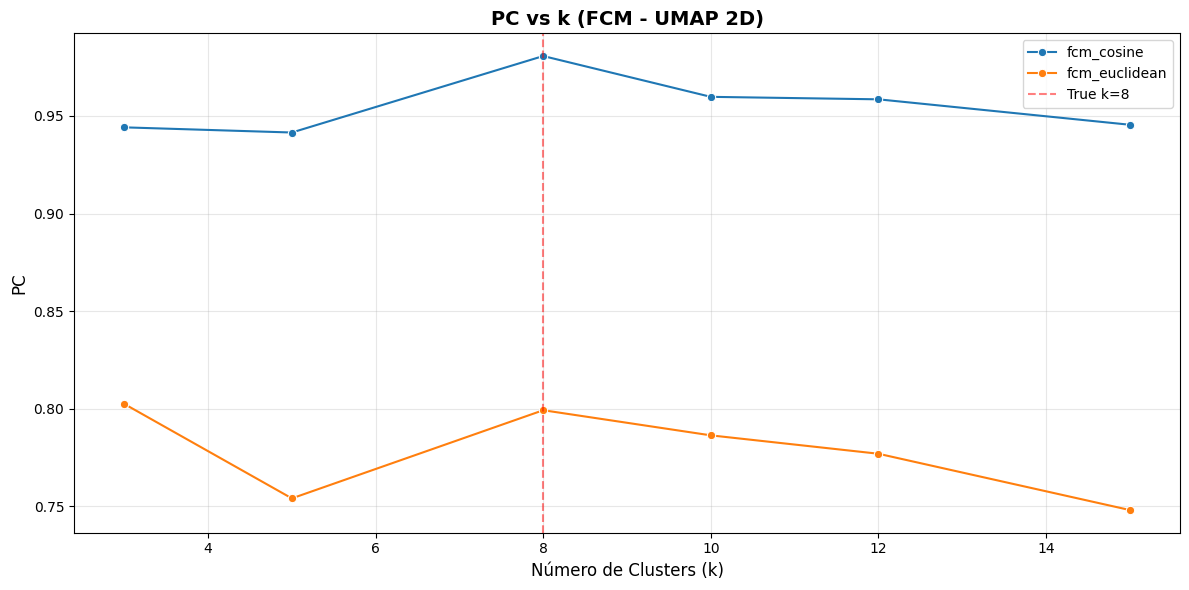

Guardada: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/04_clustering_experiments/figures/umap_fcm_pc_vs_k.png


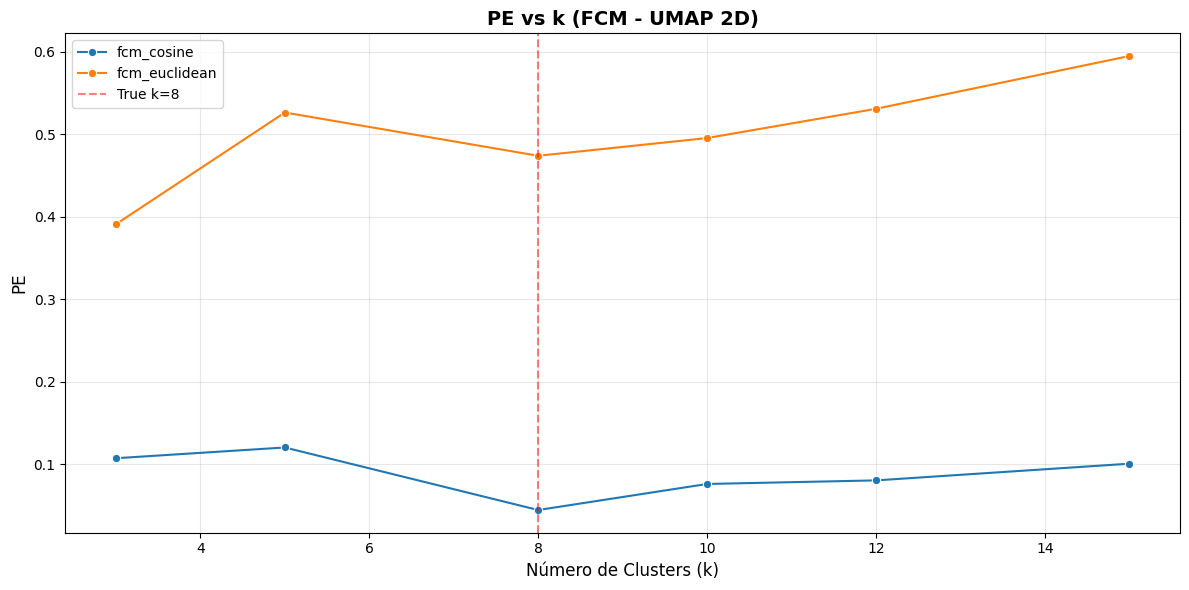

Guardada: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/04_clustering_experiments/figures/umap_fcm_pe_vs_k.png


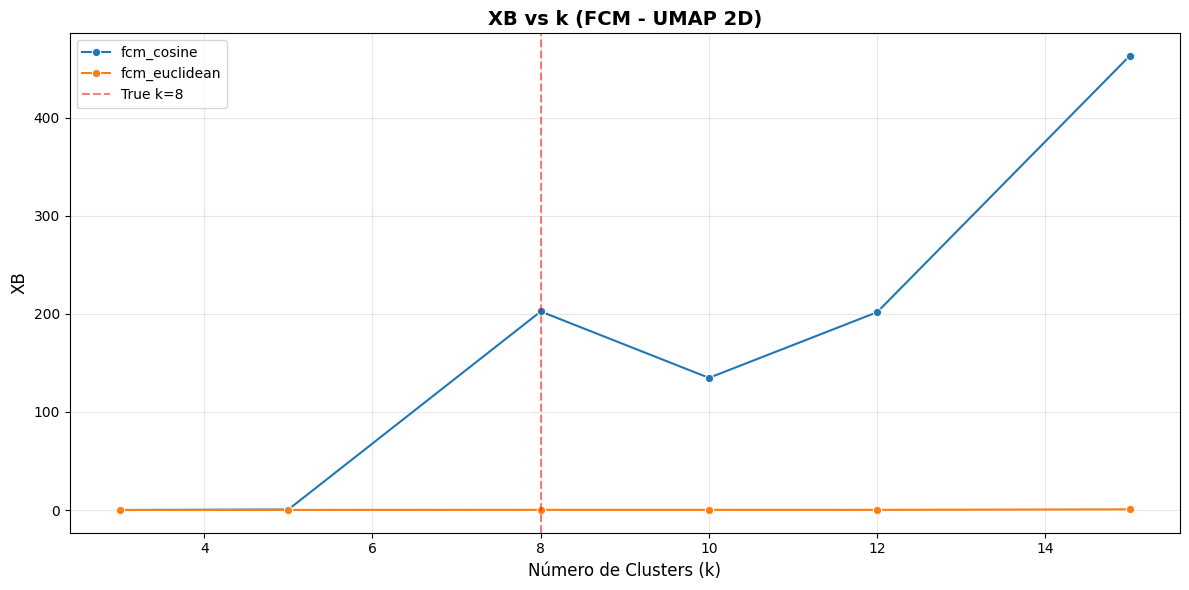

Guardada: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/04_clustering_experiments/figures/umap_fcm_xb_vs_k.png


In [13]:
# Gráficas de métricas FCM específicas (PC, PE, XB) para clustering UMAP
fcm_metrics = ['PC', 'PE', 'XB']
results_fcm_umap = results_umap_summary[results_umap_summary['Algorithm'].str.contains('fcm')]

for metric in fcm_metrics:
    if metric in results_fcm_umap.columns:
        fig, ax = plt.subplots(figsize=(12, 6))
        sns.lineplot(data=results_fcm_umap, x='k', y=metric, hue='Algorithm', marker='o', ax=ax)
        ax.set_title(f'{metric} vs k (FCM - UMAP 2D)', fontsize=14, fontweight='bold')
        ax.set_xlabel('Número de Clusters (k)', fontsize=12)
        ax.set_ylabel(metric, fontsize=12)
        ax.axvline(x=8, color='red', linestyle='--', alpha=0.5, label='True k=8')
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f"umap_fcm_{metric.lower()}_vs_k.png", dpi=180, bbox_inches='tight')
        plt.show()
        print(f"Guardada: {FIGURES_DIR / f'umap_fcm_{metric.lower()}_vs_k.png'}")


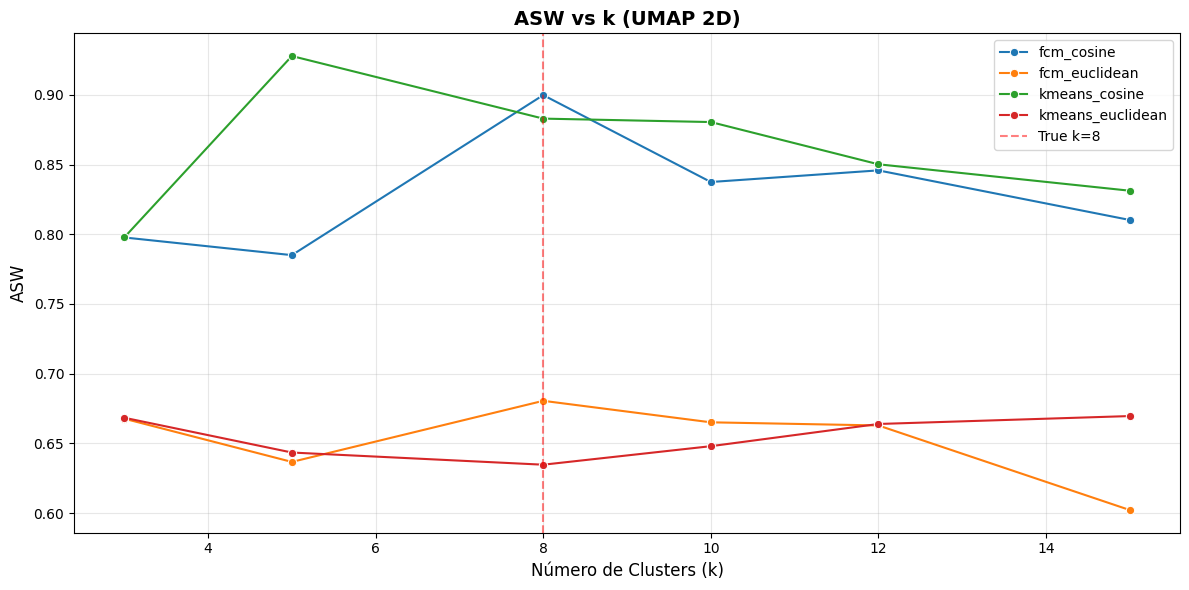

Guardada: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/04_clustering_experiments/figures/umap_asw_vs_k.png


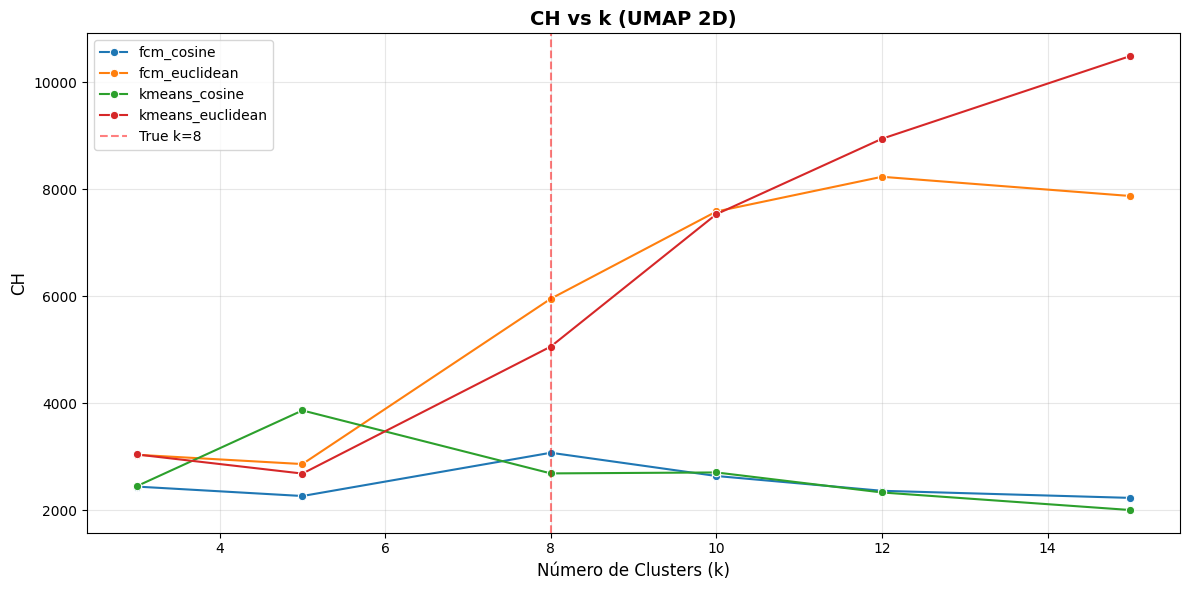

Guardada: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/04_clustering_experiments/figures/umap_ch_vs_k.png


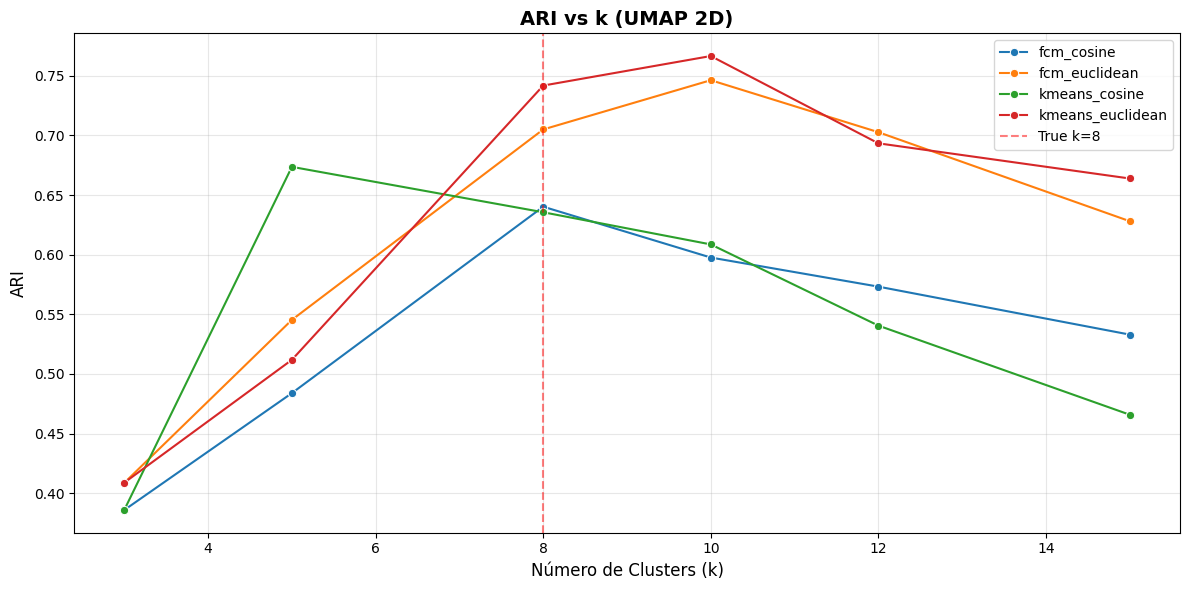

Guardada: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/04_clustering_experiments/figures/umap_ari_vs_k.png


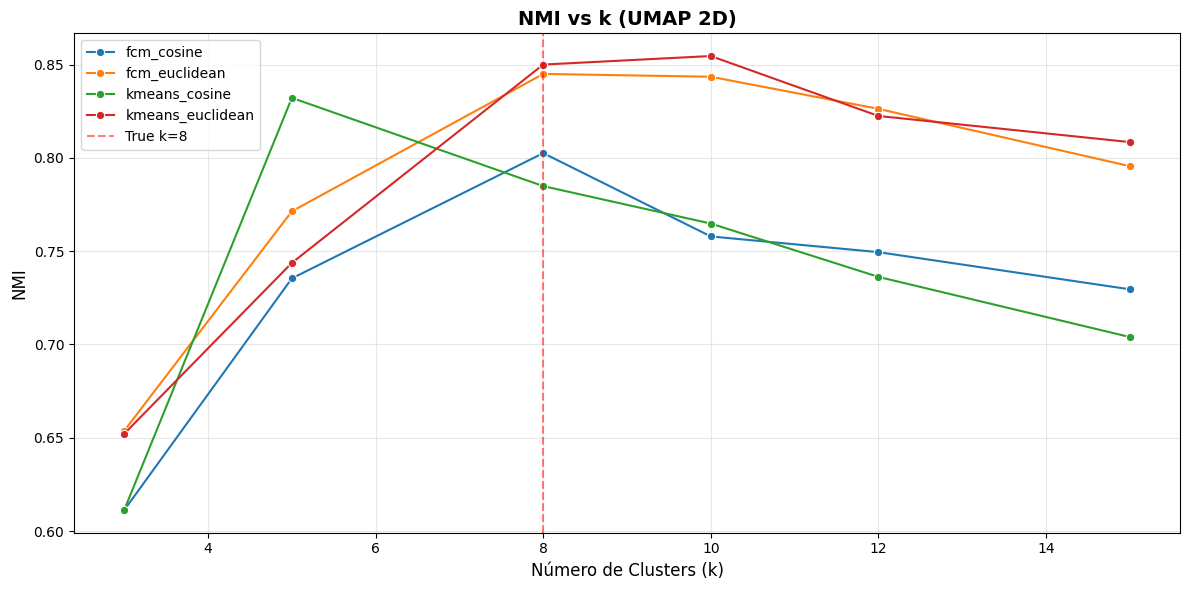

Guardada: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/04_clustering_experiments/figures/umap_nmi_vs_k.png


In [14]:
# Gráficas individuales para el clustering sobre UMAP 2D
metrics_to_plot = ['ASW', 'CH', 'ARI', 'NMI']

for metric in metrics_to_plot:
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.lineplot(data=results_umap_summary, x='k', y=metric, hue='Algorithm', marker='o', ax=ax)
    ax.set_title(f'{metric} vs k (UMAP 2D)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Número de Clusters (k)', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.axvline(x=8, color='red', linestyle='--', alpha=0.5, label='True k=8')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"umap_{metric.lower()}_vs_k.png", dpi=180, bbox_inches='tight')
    plt.show()
    print(f"Guardada: {FIGURES_DIR / f'umap_{metric.lower()}_vs_k.png'}")


### Gráficas Individuales - Clustering UMAP 2D

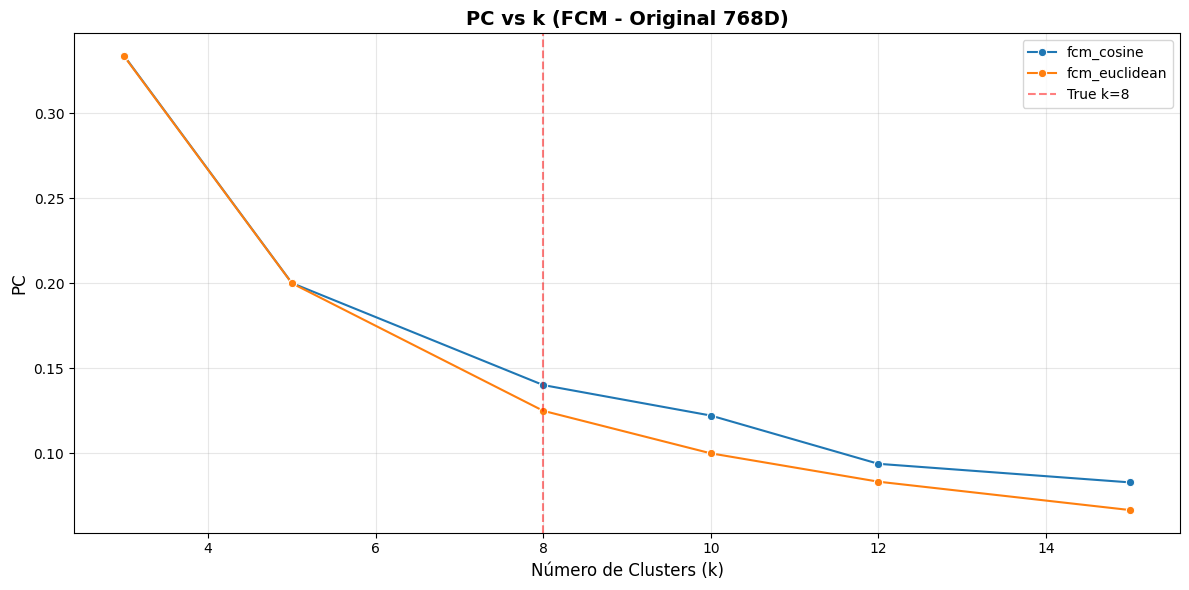

Guardada: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/04_clustering_experiments/figures/original_fcm_pc_vs_k.png


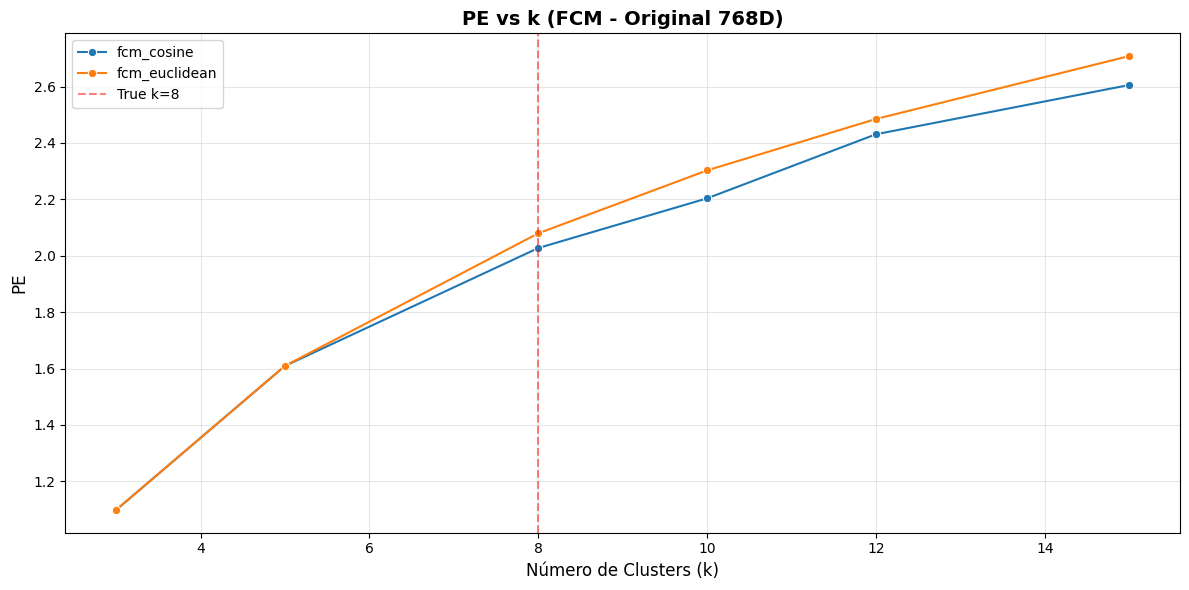

Guardada: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/04_clustering_experiments/figures/original_fcm_pe_vs_k.png


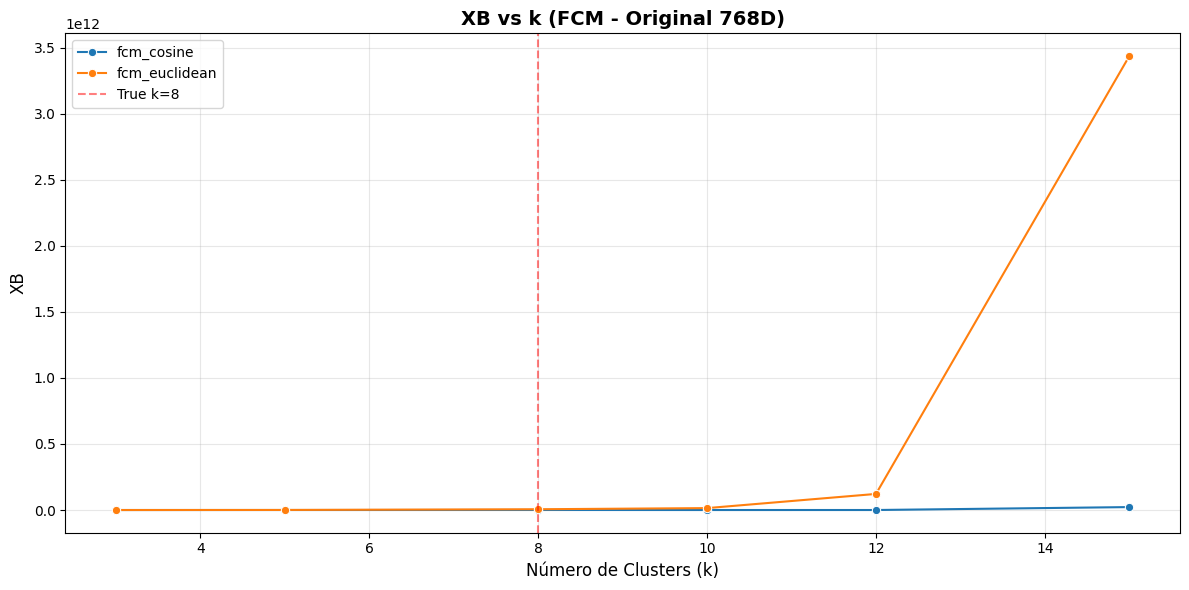

Guardada: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/04_clustering_experiments/figures/original_fcm_xb_vs_k.png


In [15]:
# Gráficas de métricas FCM específicas (PC, PE, XB) para clustering original
fcm_metrics = ['PC', 'PE', 'XB']

# Filtrar solo resultados de FCM
results_fcm = results_summary[results_summary['Algorithm'].str.contains('fcm')]

for metric in fcm_metrics:
    if metric in results_fcm.columns:
        fig, ax = plt.subplots(figsize=(12, 6))
        sns.lineplot(data=results_fcm, x='k', y=metric, hue='Algorithm', marker='o', ax=ax)
        ax.set_title(f'{metric} vs k (FCM - Original 768D)', fontsize=14, fontweight='bold')
        ax.set_xlabel('Número de Clusters (k)', fontsize=12)
        ax.set_ylabel(metric, fontsize=12)
        ax.axvline(x=8, color='red', linestyle='--', alpha=0.5, label='True k=8')
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f"original_fcm_{metric.lower()}_vs_k.png", dpi=180, bbox_inches='tight')
        plt.show()
        print(f"Guardada: {FIGURES_DIR / f'original_fcm_{metric.lower()}_vs_k.png'}")


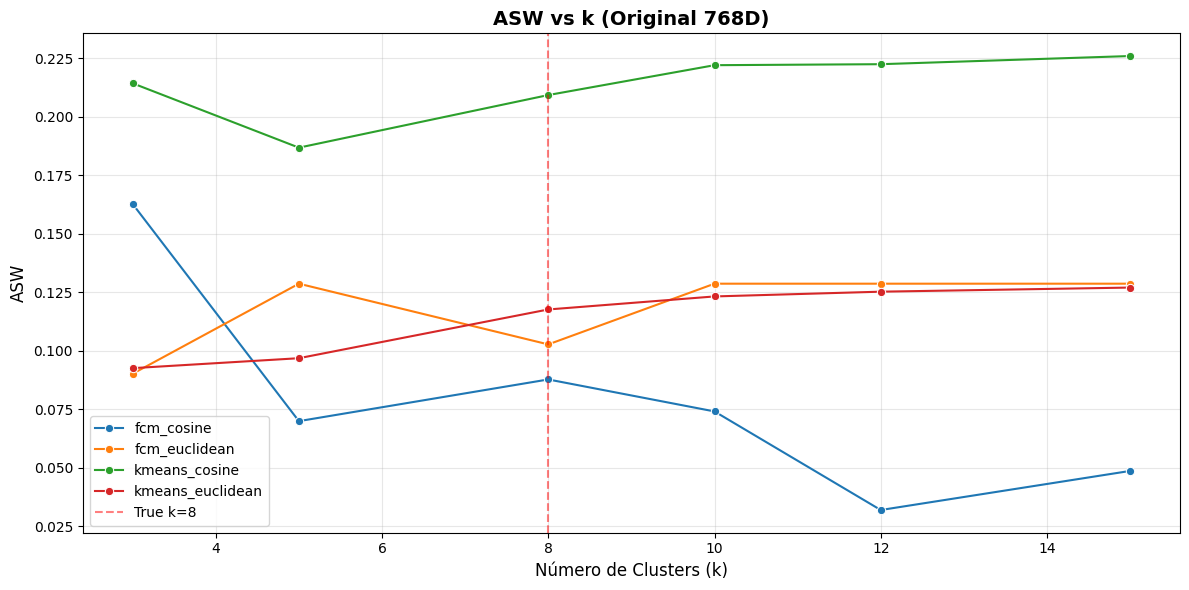

Guardada: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/04_clustering_experiments/figures/original_asw_vs_k.png


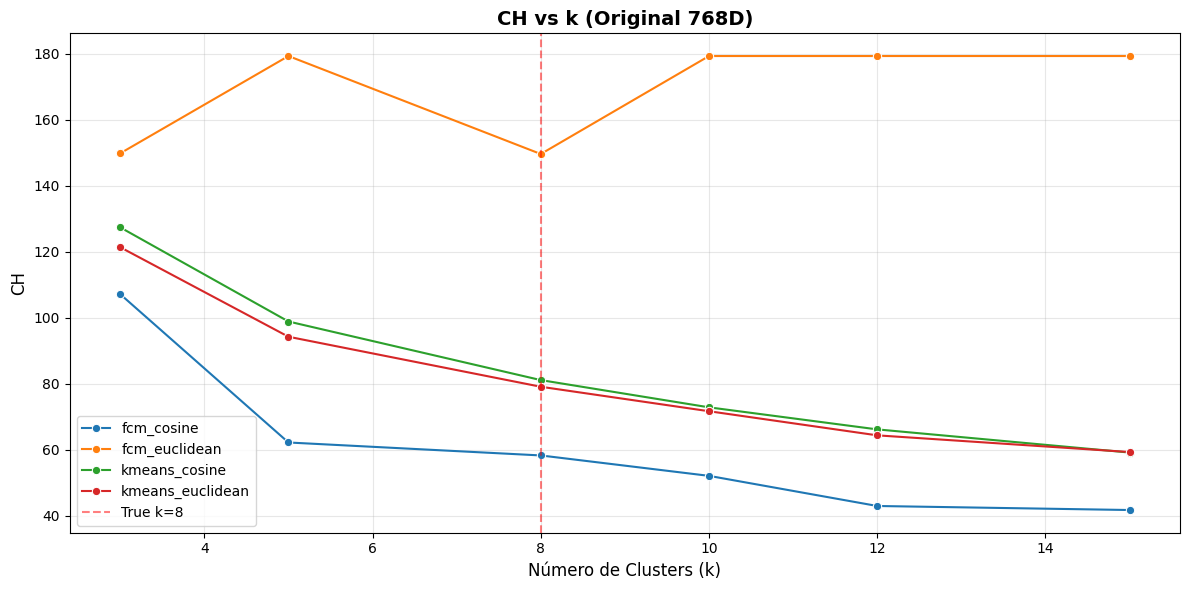

Guardada: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/04_clustering_experiments/figures/original_ch_vs_k.png


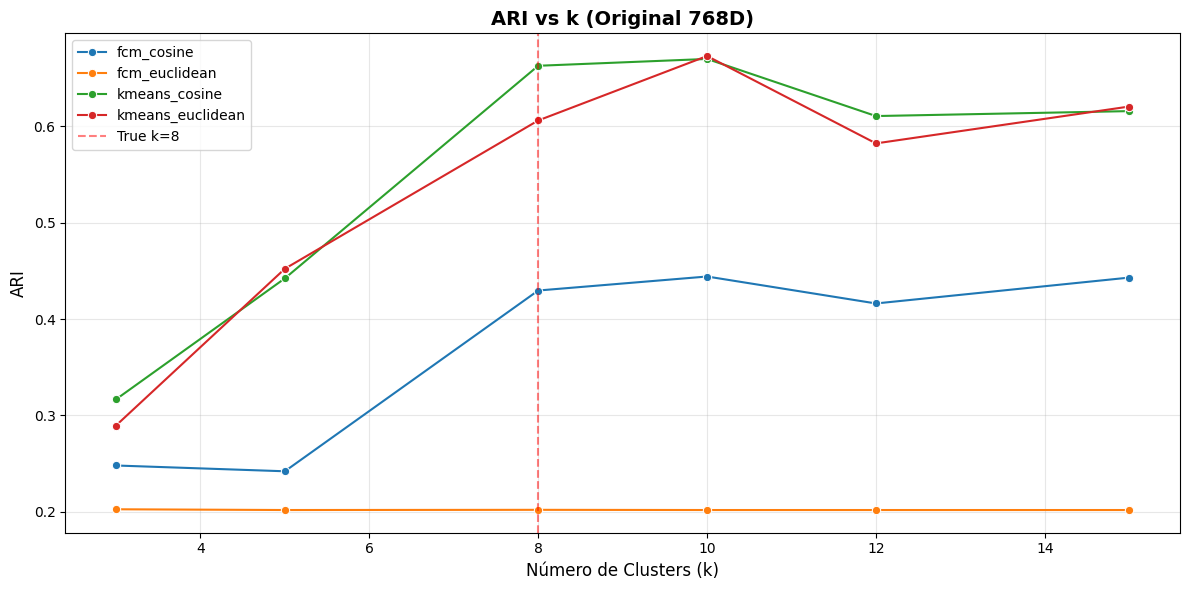

Guardada: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/04_clustering_experiments/figures/original_ari_vs_k.png


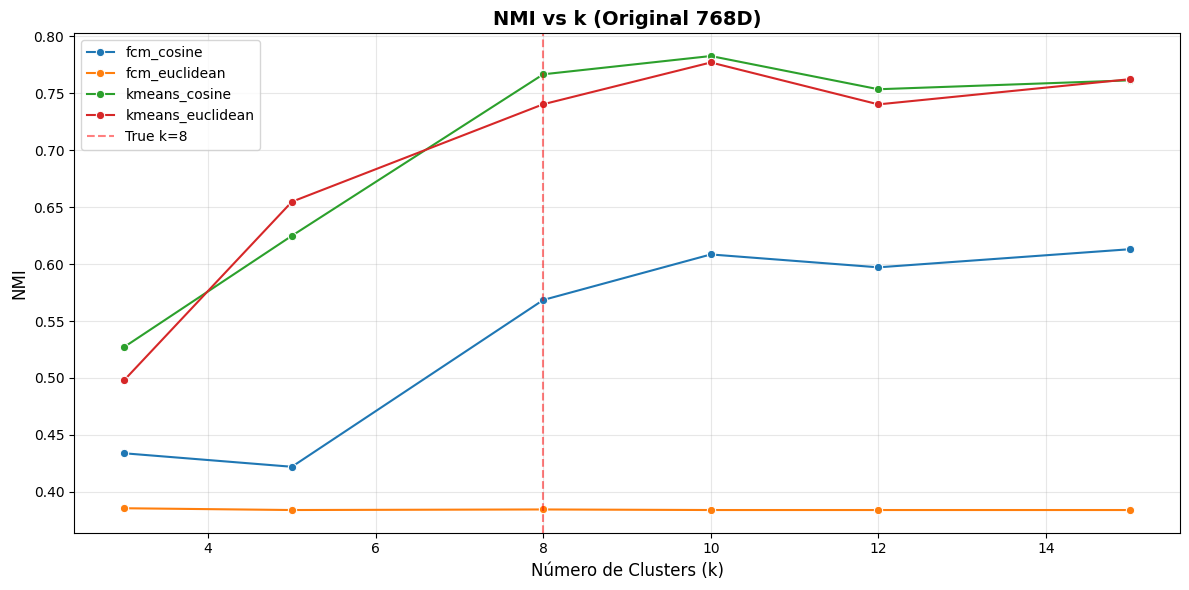

Guardada: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/04_clustering_experiments/figures/original_nmi_vs_k.png


In [16]:
# Gráficas individuales para el clustering original
metrics_to_plot = ['ASW', 'CH', 'ARI', 'NMI']

for metric in metrics_to_plot:
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.lineplot(data=results_summary, x='k', y=metric, hue='Algorithm', marker='o', ax=ax)
    ax.set_title(f'{metric} vs k (Original 768D)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Número de Clusters (k)', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.axvline(x=8, color='red', linestyle='--', alpha=0.5, label='True k=8')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"original_{metric.lower()}_vs_k.png", dpi=180, bbox_inches='tight')
    plt.show()
    print(f"Guardada: {FIGURES_DIR / f'original_{metric.lower()}_vs_k.png'}")


### Gráficas Individuales - Clustering Original (768D)

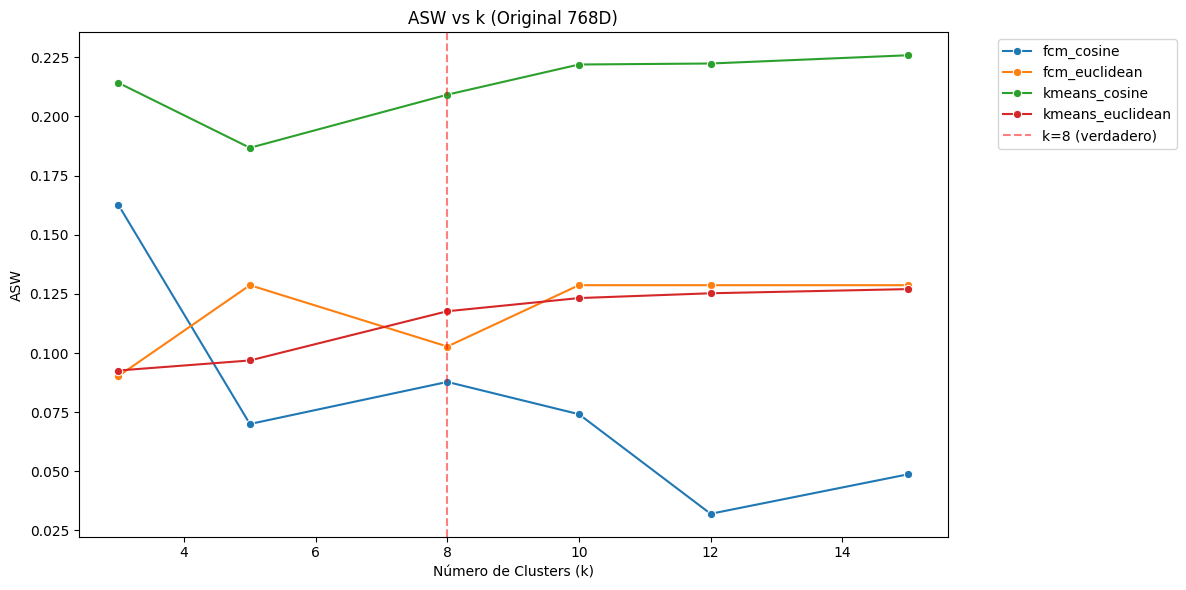

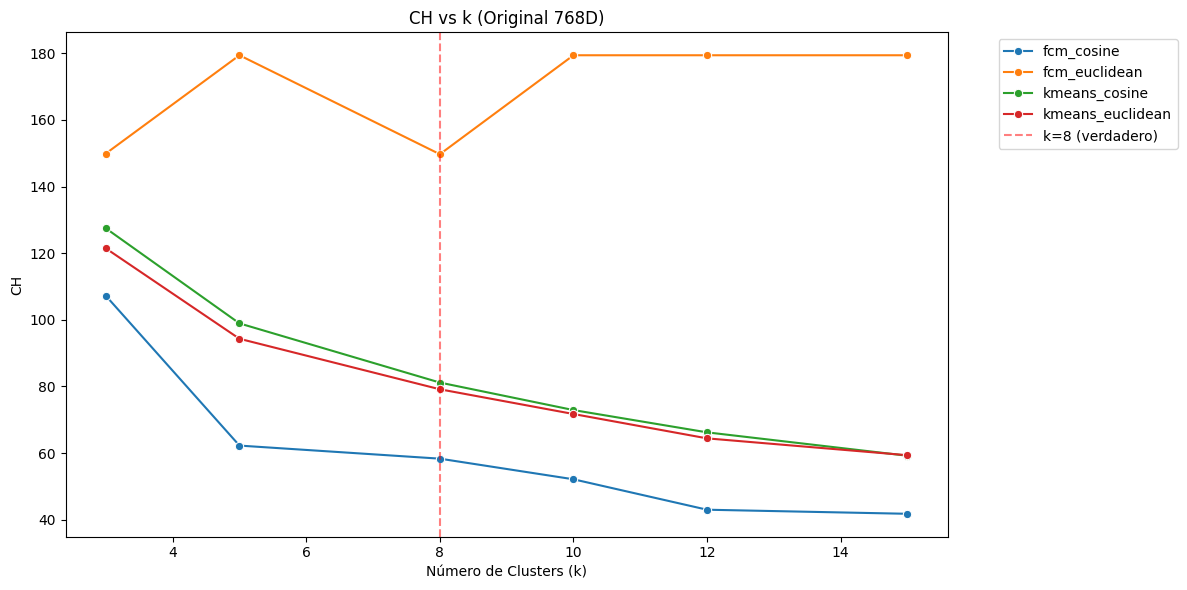

In [17]:
# Gráficas individuales para cada métrica - Clustering Original
metrics_internal = ['ASW', 'CH']
metrics_fuzzy = ['PC', 'PE', 'XB']
metrics_external = ['ARI', 'NMI']

# Métricas internas (ASW, CH disponibles para todos)
for metric in metrics_internal:
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.lineplot(data=results_summary, x='k', y=metric, hue='Algorithm', marker='o', ax=ax)
    ax.set_title(f'{metric} vs k (Original 768D)')
    ax.set_ylabel(metric)
    ax.set_xlabel('Número de Clusters (k)')
    ax.axvline(x=8, color='red', linestyle='--', alpha=0.5, label='k=8 (verdadero)')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"original_{metric.lower()}_vs_k.png", dpi=180, bbox_inches="tight")
    plt.show()


### Gráficas Individuales - Clustering Original (768D)

## 7. Cargar Resultados Guardados y Generar Gráficas Individuales
Para reutilizar resultados sin reejecutar los experimentos, cargamos los CSVs guardados previamente.
